# Houses Data: EDA & PCA (R)

This notebook performs a quick exploratory data analysis (EDA) and principal components analysis (PCA) on `data/houses.csv`.

It will:
1. Load the dataset and show a quick summary.
2. Select numeric columns and compute the covariance and correlation matrices.
3. Make scatter plots for selected pairs (and an optional `GGally::ggpairs` panel if you wish).
4. Compute eigenvalues of the covariance and correlation matrices and draw scree plots.

**Note:** This notebook assumes R and the packages listed below are available in your environment. If not, run the installation cell.


In [6]:
# Install (if needed) and load required packages
need <- c("tidyverse", "GGally", "corrplot", "gridExtra", "scales")
to_install <- need[!need %in% rownames(installed.packages())]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}
invisible(lapply(need, library, character.only = TRUE))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [2]:
# 1) Load data
path <- "data/houses.csv"
stopifnot(file.exists(path))
houses <- read.csv(path, header = TRUE)

# Glimpse
cat("\nData dimensions:", paste(dim(houses), collapse = " x "), "\n\n")
print(head(houses, 5))
cat("\nStructure:\n")
str(houses)

# Select numeric columns only (for correlations/PCA)
num_cols <- names(houses)[sapply(houses, is.numeric)]
houses_num <- houses[, num_cols, drop = FALSE]

cat("\nNumeric columns (", length(num_cols), "):\n", paste(num_cols, collapse=", "), "\n", sep = "")

# Optionally drop rows with too many NAs for EDA calculations
houses_num_cc <- houses_num[stats::complete.cases(houses_num), , drop = FALSE]
cat("\nRows after complete-cases filter:", nrow(houses_num_cc), "\n")



Data dimensions: 20640 x 9 

  median_house_value median_income housing_median_age total_rooms
1             452600        8.3252                 41         880
2             358500        8.3014                 21        7099
3             352100        7.2574                 52        1467
4             341300        5.6431                 52        1274
5             342200        3.8462                 52        1627
  total_bedrooms population households latitude longitude
1            129        322        126    37.88   -122.23
2           1106       2401       1138    37.86   -122.22
3            190        496        177    37.85   -122.24
4            235        558        219    37.85   -122.25
5            280        565        259    37.85   -122.25

Structure:
'data.frame':	20640 obs. of  9 variables:
 $ median_house_value: num  452600 358500 352100 341300 342200 ...
 $ median_income     : num  8.33 8.3 7.26 5.64 3.85 ...
 $ housing_median_age: num  41 21 52 52 52 52 52 


Covariance matrix (first 6x6 block):
                   median_house_value median_income housing_median_age
median_house_value      13316148163.0    150847.483         153398.801
median_income                150847.5         3.609             -2.846
housing_median_age           153398.8        -2.846            158.396
total_rooms                33772890.2       820.852          -9919.120
total_bedrooms              2459372.2        -6.477          -1699.094
population                 -3221248.7        10.401          -4222.271
                    total_rooms total_bedrooms   population
median_house_value 33772890.187    2459372.247 -3221248.729
median_income           820.852         -6.477       10.401
housing_median_age    -9919.120      -1699.094    -4222.271
total_rooms         4759445.106     854572.783  2117612.546
total_bedrooms       854572.783     177449.798   418859.730
population          2117612.546     418859.730  1282470.457

Correlation matrix (first 6x6 block):
      

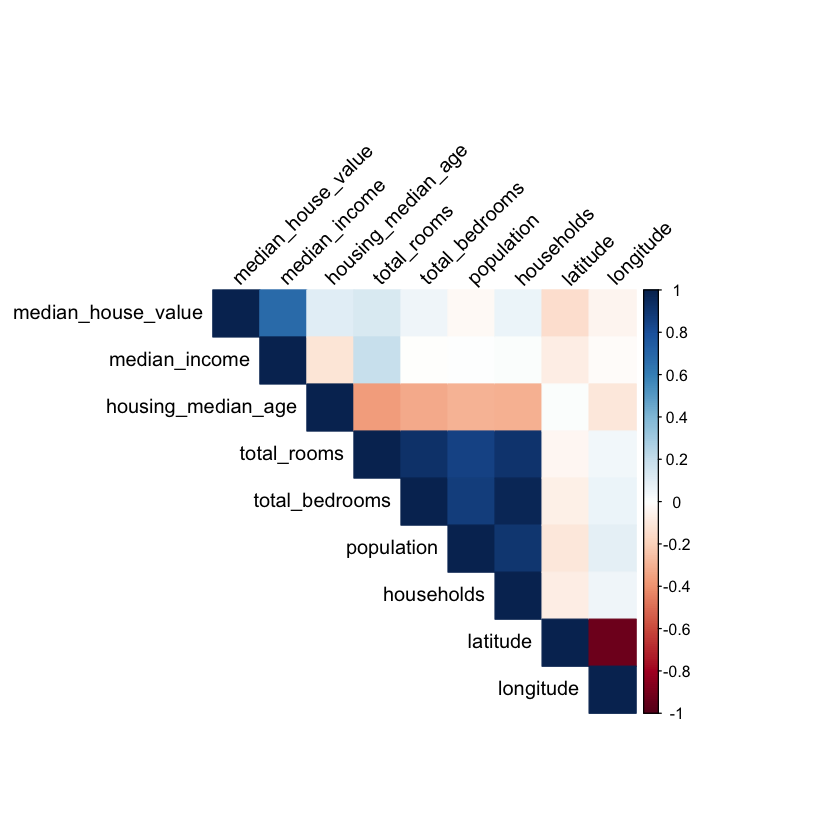

In [3]:
# 2) Covariance and correlation matrices
cov_mat <- cov(houses_num_cc)
cor_mat <- cor(houses_num_cc)

cat("\nCovariance matrix (first 6x6 block):\n")
print(round(cov_mat[1:min(6,ncol(cov_mat)), 1:min(6,ncol(cov_mat))], 3))

cat("\nCorrelation matrix (first 6x6 block):\n")
print(round(cor_mat[1:min(6,ncol(cor_mat)), 1:min(6,ncol(cor_mat))], 3))

# Visualize correlation matrix
corrplot::corrplot(cor_mat, method = "color", type = "upper", tl.col = "black", tl.srt = 45,
                   addCoef.col = NULL, number.cex = 0.6, mar = c(0,0,1,0))


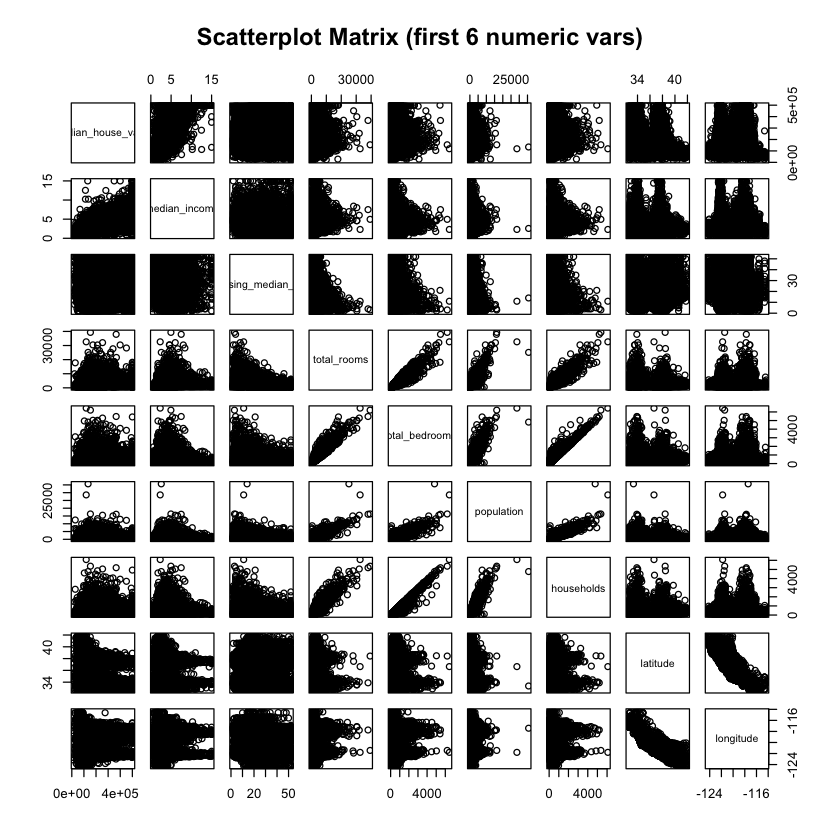

In [4]:
# 3) Scatter plots for selected pairs
# Pick up to 4-6 numeric variables for compact visuals
vars_for_pairs <- head(num_cols, 9)
if (length(vars_for_pairs) >= 2) {
  # Base pairs plot
  pairs(houses_num_cc[, vars_for_pairs], main = "Scatterplot Matrix (first 6 numeric vars)")
  
  # Optional: GGally panel (comment out if too slow for large data)
  # GGally::ggpairs(houses_num_cc[, vars_for_pairs])
} else {
  warning("Not enough numeric columns to create scatter plots.")
}


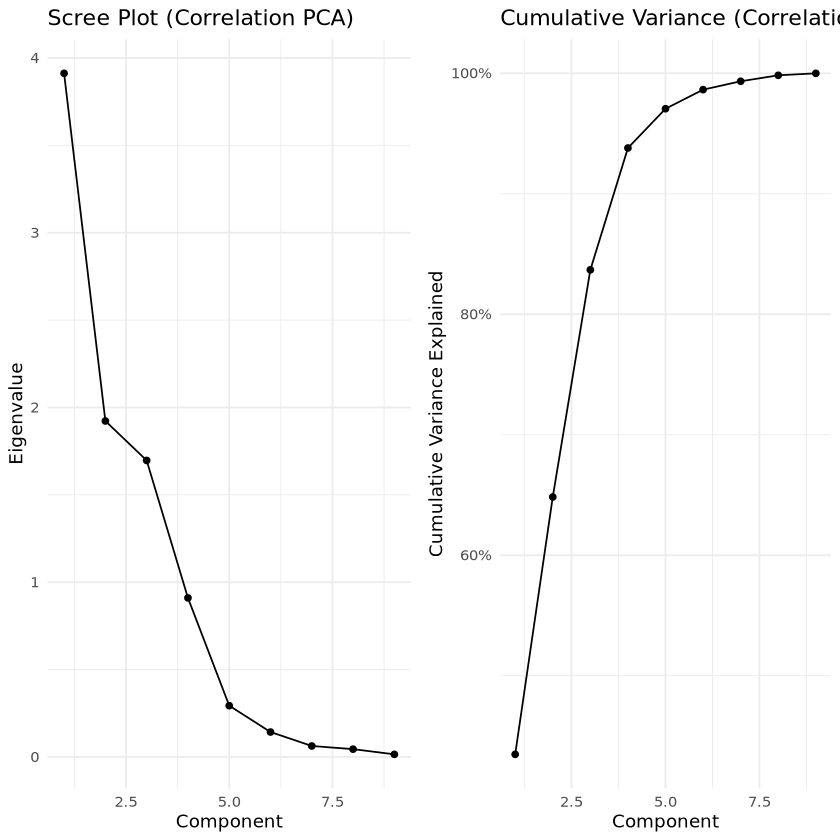

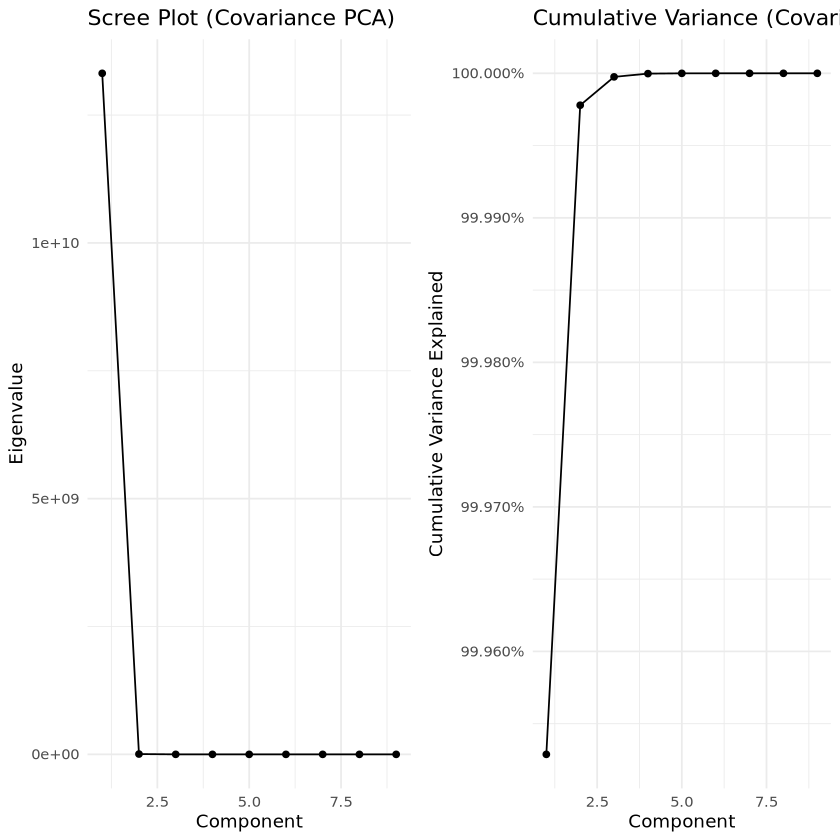

In [10]:
# 4) PCA eigenvalues and scree plots
# From correlation matrix (standardized PCA)
eig_cor <- eigen(cor_mat, symmetric = TRUE)
lambda_cor <- eig_cor$values
prop_cor <- lambda_cor / sum(lambda_cor)
cum_cor <- cumsum(prop_cor)

# From covariance matrix (unstandardized PCA)
eig_cov <- eigen(cov_mat, symmetric = TRUE)
lambda_cov <- eig_cov$values
prop_cov <- lambda_cov / sum(lambda_cov)
cum_cov <- cumsum(prop_cov)

# Scree plot (correlation)
df_cor <- data.frame(Component = seq_along(lambda_cor),
                     Eigenvalue = lambda_cor,
                     Proportion = prop_cor,
                     Cumulative = cum_cor)

library(ggplot2)
p1 <- ggplot(df_cor, aes(x = Component, y = Eigenvalue)) +
  geom_point() + geom_line() +
  ggtitle("Scree Plot (Correlation PCA)") +
  theme_minimal()

p2 <- ggplot(df_cor, aes(x = Component, y = Cumulative)) +
  geom_point() + geom_line() +
  scale_y_continuous(labels = scales::percent_format()) +
  ylab("Cumulative Variance Explained") +
  ggtitle("Cumulative Variance (Correlation PCA)") +
  theme_minimal()

gridExtra::grid.arrange(p1, p2, ncol = 2)

# Scree plot (covariance)
df_cov <- data.frame(Component = seq_along(lambda_cov),
                     Eigenvalue = lambda_cov,
                     Proportion = prop_cov,
                     Cumulative = cum_cov)

p3 <- ggplot(df_cov, aes(x = Component, y = Eigenvalue)) +
  geom_point() + geom_line() +
  ggtitle("Scree Plot (Covariance PCA)") +
  theme_minimal()

p4 <- ggplot(df_cov, aes(x = Component, y = Cumulative)) +
  geom_point() + geom_line() +
  scale_y_continuous(labels = scales::percent_format()) +
  ylab("Cumulative Variance Explained") +
  ggtitle("Cumulative Variance (Covariance PCA)") +
  theme_minimal()

gridExtra::grid.arrange(p3, p4, ncol = 2)


## Notes
- `cor(houses_num_cc)` uses rows with complete numeric cases to avoid NA propagation in the correlation matrix.
- The correlation-based PCA is often preferred when variables are on very different scales.
- You can customize `vars_for_pairs` to the specific columns you want to visualize.
